In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def sistema(t, estado, m, gamma, g=9.81):
    y, v = estado

    dydt = v
    dvdt = g - (gamma / m) * v**2

    return [dydt, dvdt]

In [5]:
def runge_kutta2(m, gamma, y0, v0, t0, h, altura_torre, g=9.81, tf_max=100):
    t_valores = [t0]
    y_valores = [y0]
    v_valores = [v0]

    t = t0
    estado = [y0, v0]

    while estado[0] < altura_torre and t < tf_max:
        # k1 = pendiente al inicio del intervalo
        k1 = sistema(t, estado, m, gamma, g)

        # Estado aproximado en la mitad del paso
        estado_medio = [
            estado[0] + (h / 2) * k1[0],
            estado[1] + (h / 2) * k1[1]
        ]

        # k2 = pendiente en el punto medio
        k2 = sistema(t + h / 2, estado_medio, m, gamma, g)

        # Actualización del estado
        estado = [
            estado[0] + h * k2[0],
            estado[1] + h * k2[1]
        ]

        t = t + h

        t_valores.append(t)
        y_valores.append(estado[0])
        v_valores.append(estado[1])

    return np.array(t_valores), np.array(y_valores), np.array(v_valores)

In [6]:
altura_torre = 55.8

# Bala de cañón
m_c = 16
gamma_c = 0.0058

# Bala de mosquete
m_m = 0.0082
gamma_m = 3.74e-5

# Condiciones iniciales
y0 = 0
v0 = 0
t0 = 0
h = 0.01

t_c, y_c, v_c = runge_kutta2(m_c, gamma_c, y0, v0, t0, h, altura_torre)
t_m, y_m, v_m = runge_kutta2(m_m, gamma_m, y0, v0, t0, h, altura_torre)

tiempo_canon = t_c[-1]
tiempo_mosquete = t_m[-1]

print(f"Tiempo bala de cañón: {tiempo_canon:.4f} s")
print(f"Tiempo bala de mosquete: {tiempo_mosquete:.4f} s")

Tiempo bala de cañón: 3.3900 s
Tiempo bala de mosquete: 3.5200 s


In [7]:
indice_canon = len(t_c) - 1
y_m_en_tcanon = y_m[indice_canon]
distancia_al_suelo = altura_torre - y_m_en_tcanon

print(f"Cuando la bala de cañón toca el piso, a la de mosquete le faltan {distancia_al_suelo:.4f} m para llegar al suelo")

Cuando la bala de cañón toca el piso, a la de mosquete le faltan 3.6882 m para llegar al suelo


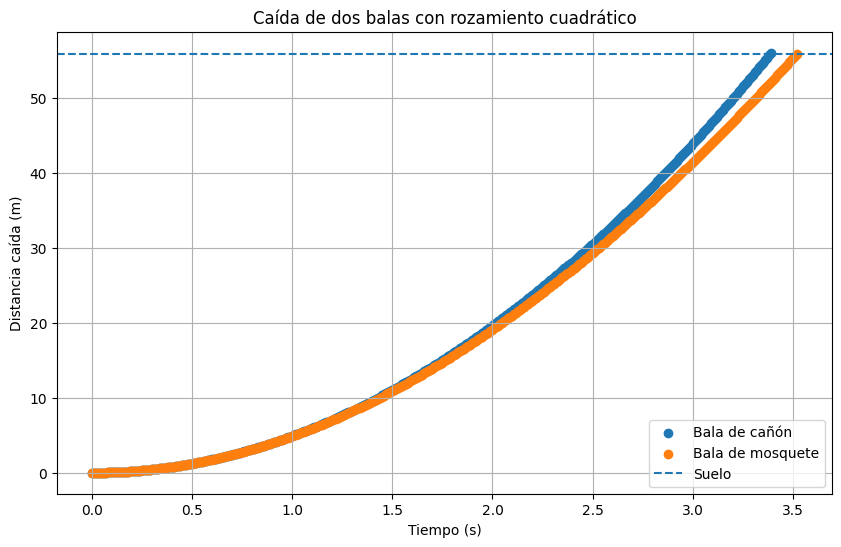

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(t_c, y_c, label='Bala de cañón')
plt.scatter(t_m, y_m, label='Bala de mosquete')
plt.axhline(altura_torre, linestyle='--', label='Suelo')

plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia caída (m)')
plt.title('Caída de dos balas con rozamiento cuadrático')
plt.legend()
plt.grid(True)
plt.show()